In [7]:
import os
import torch

# load all environment variables from .env file
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Keys

In [10]:
BASE_DIR = os.getenv("BASE_DIR", ".")
save_path = os.path.join(BASE_DIR, "model_outputs.pt")

tensors = torch.load(save_path, weights_only=False)

print(tensors.keys())

dict_keys(['input_ids', 'labels', 'loss', 'logits', 'past_key_values'])


In [11]:
pkv = tensors['past_key_values']  # Expect a DynamicCache object

# retrieve all keys into a single tensor of shape (B, T, L, H, head_dim) - B=batch size, T=sequence length, L=number of layers, H=number of heads, head_dim=head dimension
all_keys = []
for layer_idx, layer_cache in enumerate(pkv.layers):
    all_keys.append(layer_cache.keys)

keys = torch.stack(all_keys, dim=2)  # shape (B, T, L, H, head_dim)
print("All keys tensor shape:", keys.shape)

All keys tensor shape: torch.Size([4, 8, 16, 1024, 64])


# Metrics

In [22]:
def mse(a, b):
    return ((a - b) ** 2).mean()

def abs_error(a, b):
    return (a - b).abs().sum(dim=(-1,-2)).mean()

def relative_error(a, b):
    return ((a - b).abs().sum() / a.abs().sum().clamp(min=1e-12))

def compute_svd_error(A, U, S, V, error_fn):
    # Reconstruct A from U, S, V
    A_reconstructed = (U * S.unsqueeze(-2)) @ V
    return error_fn(A, A_reconstructed)

def compression_ratio(A, U, S, V):
    original_size = A.numel()
    compressed_size = U.numel() + V.numel()
    return original_size / compressed_size

def print_all_errors(A, U, S, V):
    print("MSE:", compute_svd_error(A, U, S, V, mse).item())
    print("Absolute Error:", compute_svd_error(A, U, S, V, abs_error).item())
    print("Relative Error:", compute_svd_error(A, U, S, V, relative_error).item())
    print("Compression Ratio:", compression_ratio(A, U, S, V))

# SVD

### Truncated SVD

In [13]:
from utils import full_svd, truncated_svd

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
full_svd_keys = full_svd(keys)
U, S, V = full_svd_keys
print("keys.shape:", keys.shape)
print("U.shape:", U.shape)
print("S.shape:", S.shape)
print("V.shape:", V.shape)

keys.shape: torch.Size([4, 8, 16, 1024, 64])
U.shape: torch.Size([4, 8, 16, 1024, 64])
S.shape: torch.Size([4, 8, 16, 64])
V.shape: torch.Size([4, 8, 16, 64, 64])


In [15]:
trunc_svd_keys = truncated_svd(keys, 4)
U, S, V = trunc_svd_keys
print("keys.shape:", keys.shape)
print("U.shape:", U.shape)
print("S.shape:", S.shape)
print("V.shape:", V.shape)

keys.shape: torch.Size([4, 8, 16, 1024, 64])
U.shape: torch.Size([4, 8, 16, 1024, 4])
S.shape: torch.Size([4, 8, 16, 4])
V.shape: torch.Size([4, 8, 16, 4, 64])


In [16]:
full_svd_keys = full_svd(keys)
print(" ===== Errors for full SVD:")
print_all_errors(keys, *full_svd_keys)

 ===== Errors for full SVD:
MSE: 7.772445678710938e-05
Absolute Error: 290.0
Relative Error: 0.0025634765625
Compression Ratio: 0.9403122130394858


<Figure size 1000x600 with 0 Axes>

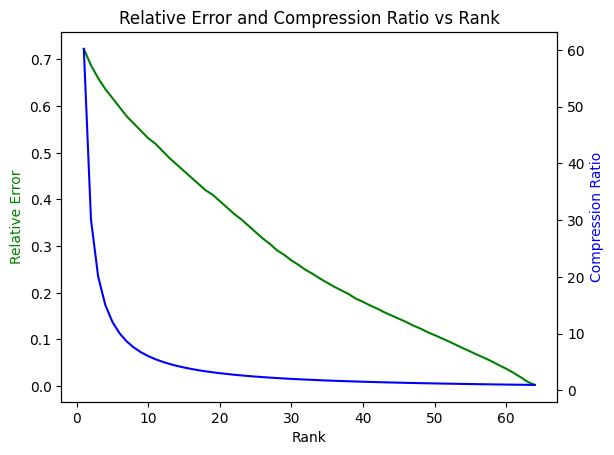

In [ ]:
import matplotlib.pyplot as plt

truncated_svd_keys = {}
ranks = list(range(1, keys.shape[-1] + 1))
plt.figure(figsize=(10, 6))
for rank in ranks:
    truncated_svd_keys[rank] = {'trunc_keys': truncated_svd(keys, rank)}
    truncated_svd_keys[rank]['relative_err'] = compute_svd_error(
        keys, *(truncated_svd_keys[rank]['trunc_keys']), relative_error
    ).item()
    truncated_svd_keys[rank]['compression_ratio'] = compression_ratio(
        keys, *(truncated_svd_keys[rank]['trunc_keys'])
    )


In [23]:
# re-compute compression ratios
for r in ranks:
    U, S, V = truncated_svd_keys[r]['trunc_keys']
    truncated_svd_keys[r]['compression_ratio'] = compression_ratio(
        keys, U, S, V
    )

Intercept found at rank  30


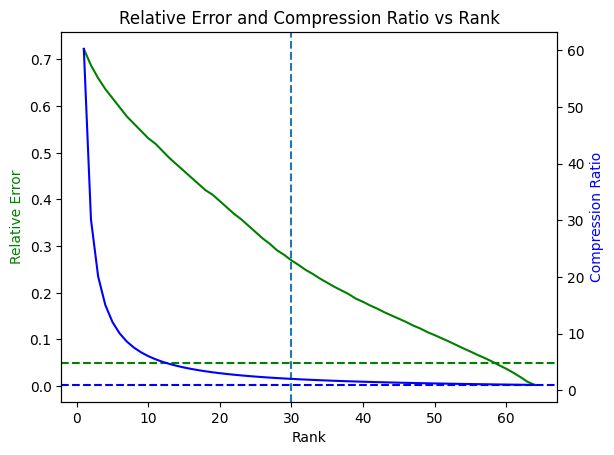

In [32]:
for i, comp_ratio in enumerate([truncated_svd_keys[rank]['compression_ratio'] for rank in ranks]):
    if comp_ratio < 2.0:
        intercept = i
        print("Intercept found at rank ", intercept)
        break

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(
    ranks, 
    [truncated_svd_keys[rank]['relative_err'] for rank in ranks], 
    'g-', label='Relative Error'
)
ax2.plot(
    ranks, 
    [truncated_svd_keys[rank]['compression_ratio'] for rank in ranks], 
    'b-',
    label='Compression Ratio'
)
ax1.set_xlabel('Rank')
ax1.set_ylabel('Relative Error', color='g')
# make horizontal line at 0.05
ax1.axhline(y=0.05, color='g', linestyle='--')
ax1.axvline(x=intercept, linestyle='--')
ax2.set_ylabel('Compression Ratio', color='b')
# make horizontal line at 1.0
ax2.axhline(y=1.0, color='b', linestyle='--')
plt.title('Relative Error and Compression Ratio vs Rank')
plt.show()